# PCA Scatter — Raw Activation Vectors from MongoDB

Projects the raw last-token `SelfAttention.o` activation vectors from two scan
groups (correct False vs hallucinated True) into 2D using PCA, then plots them
as a scatter to visualise geometric separation between the groups.

Data acquisition mirrors `last_token_vector_from_mongo.ipynb` exactly:
same MongoDB filters, same group size, same layer extraction.

## Cell 1 — Imports

In [ ]:
import sys, os

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from scipy.spatial import ConvexHull

from neuralsignal.backend.ns_backend import NSBackend

print(f"torch   : {torch.__version__}")
print(f"sklearn : imported OK")

## Cell 2 — Config

- `LAYER_INDEX`: which `SelfAttention.o` layer to read from. `-2` = penultimate
  (strongest separation found in prior analysis). `-1` = final layer.
- All other settings match `last_token_vector_from_mongo.ipynb`.

In [9]:
APPLICATION_NAME     = "redis"
SUB_APPLICATION_NAME = "quora_duplicates_t5_large"

GROUP_SIZE   = 20
LAYER_INDEX  = -2    # -2 = penultimate SelfAttention.o layer (peak separation)
DEVICE       = "cpu"

FILTER_FALSE = {"ground_truth": "0", "decoded_output": "Fal"}
FILTER_TRUE  = {"ground_truth": "0", "decoded_output": "True"}

## Cell 3 — Connect to backend & load scan groups

In [10]:
import tempfile
from neuralsignal.core.modules.neuralsignal_config import sdk_config

backend_cfg = sdk_config.get_backend_config()
backend_cfg["scan_cache_directory"] = tempfile.gettempdir()

cfg = {
    "application_name": APPLICATION_NAME,
    "sub_application_name": SUB_APPLICATION_NAME,
    "backend_config": backend_cfg,
}
be = NSBackend(cfg)

def load_group(be, mongo_filter, n):
    cursor = be.query(mongo_filter).limit(n)
    scans = []
    for doc in cursor:
        try:
            scans.append(be.deserialize_scan(doc))
        except Exception as e:
            print(f"  skipping {doc.get('_id')}: {e}")
    return scans

print("Loading False group ...")
group_false = load_group(be, FILTER_FALSE, GROUP_SIZE)
print(f"  loaded {len(group_false)} scans")

print("Loading True group ...")
group_true = load_group(be, FILTER_TRUE, GROUP_SIZE)
print(f"  loaded {len(group_true)} scans")

Loading False group ...
  loaded 20 scans
Loading True group ...
  loaded 20 scans


## Cell 4 — Extract activation vectors at chosen layer

For each scan, collect all `SelfAttention.o` layers in capture order, then
index into that list with `LAYER_INDEX` to get a single `(hidden_dim,)` vector.

In [11]:
def extract_layer_vector(scan, layer_index):
    """Return the raw last-token activation at the given SelfAttention.o layer index."""
    layer_id_to_name = scan["layer_id_to_name"]
    sa_layers = [
        lid for lid in scan["layer_order"]
        if "SelfAttention.o" in layer_id_to_name[lid]
    ]
    if not sa_layers:
        raise ValueError("No SelfAttention.o layers found.")
    lid = sa_layers[layer_index]
    tensor = scan["outputs"][lid]          # (seq_len, hidden_dim)
    return tensor[-1, :].float(), layer_id_to_name[lid]

def build_matrix(scans, layer_index, expected_dim=None):
    """Build an (N, hidden_dim) matrix of activation vectors from a scan group."""
    vectors, skipped = [], 0
    for scan in scans:
        try:
            vec, layer_name = extract_layer_vector(scan, layer_index)
            if expected_dim is not None and vec.shape[0] != expected_dim:
                skipped += 1
                continue
            vectors.append(vec)
        except Exception as e:
            skipped += 1
    if skipped:
        print(f"  skipped {skipped} scans")
    return torch.stack(vectors)   # (N, hidden_dim)

vecs_false = build_matrix(group_false, LAYER_INDEX)
vecs_true  = build_matrix(group_true,  LAYER_INDEX, expected_dim=vecs_false.shape[1])

_, layer_name = extract_layer_vector(group_false[0], LAYER_INDEX)
print(f"Layer    : {layer_name}")
print(f"False    : {vecs_false.shape}")
print(f"True     : {vecs_true.shape}")

Layer    : decoder.T5Block.T5LayerSelfAttention.SelfAttention.o
False    : torch.Size([20, 1024])
True     : torch.Size([20, 1024])


## Cell 5 — Fit PCA on both groups combined

PCA is fit on all N_false + N_true vectors together so the projection is shared.
The first two components capture the directions of maximum variance across both groups.

In [12]:
N_COMPONENTS = 10   # fit 10, plot first 2 — extra components for scree plot

all_vecs = torch.cat([vecs_false, vecs_true], dim=0).numpy()   # (N_f+N_t, D)

pca = PCA(n_components=N_COMPONENTS)
pca.fit(all_vecs)

proj_false = pca.transform(vecs_false.numpy())   # (N_f, N_COMPONENTS)
proj_true  = pca.transform(vecs_true.numpy())    # (N_t, N_COMPONENTS)

var = pca.explained_variance_ratio_ * 100
print("Explained variance per component:")
for i, v in enumerate(var):
    print(f"  PC{i+1}: {v:.2f}%")
print(f"  Total (first 2): {var[:2].sum():.2f}%")

Explained variance per component:
  PC1: 69.49%
  PC2: 16.22%
  PC3: 4.57%
  PC4: 1.38%
  PC5: 0.82%
  PC6: 0.71%
  PC7: 0.64%
  PC8: 0.59%
  PC9: 0.47%
  PC10: 0.41%
  Total (first 2): 85.71%


## Cell 6 — Scatter plot (PC1 vs PC2)

Each point is one scan. Blue = correct False, Red = hallucinated True.
Convex hulls show the extent of each group. Centroids are marked with a star.

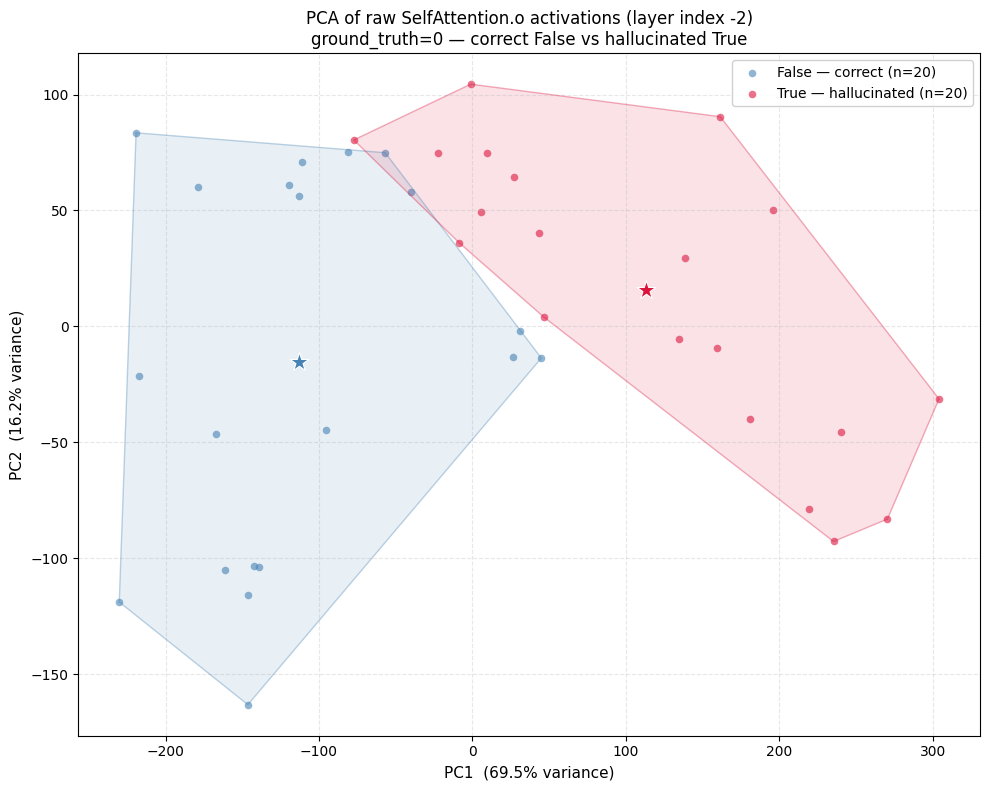

In [13]:
def draw_convex_hull(ax, points, color, alpha=0.12):
    """Draw a filled convex hull around a 2D point cloud."""
    if len(points) < 3:
        return
    try:
        hull = ConvexHull(points)
        vertices = np.append(hull.vertices, hull.vertices[0])   # close the loop
        ax.fill(points[vertices, 0], points[vertices, 1],
                color=color, alpha=alpha, linewidth=0)
        ax.plot(points[vertices, 0], points[vertices, 1],
                color=color, alpha=0.35, linewidth=1)
    except Exception:
        pass

fig, ax = plt.subplots(figsize=(10, 8))

# ── scatter points ──────────────────────────────────────────────────────────
ax.scatter(proj_false[:, 0], proj_false[:, 1],
           c="steelblue", s=30, alpha=0.6, linewidths=0, label=f"False — correct (n={len(proj_false)})")
ax.scatter(proj_true[:, 0],  proj_true[:, 1],
           c="crimson",   s=30, alpha=0.6, linewidths=0, label=f"True — hallucinated (n={len(proj_true)})")

# ── convex hulls ────────────────────────────────────────────────────────────
draw_convex_hull(ax, proj_false[:, :2], "steelblue")
draw_convex_hull(ax, proj_true[:, :2],  "crimson")

# ── centroids ───────────────────────────────────────────────────────────────
cf = proj_false[:, :2].mean(axis=0)
ct = proj_true[:, :2].mean(axis=0)
ax.scatter(*cf, c="steelblue", s=200, marker="*", zorder=5, edgecolors="white", linewidths=0.8)
ax.scatter(*ct, c="crimson",   s=200, marker="*", zorder=5, edgecolors="white", linewidths=0.8)

# ── labels & formatting ─────────────────────────────────────────────────────
ax.set_xlabel(f"PC1  ({var[0]:.1f}% variance)", fontsize=11)
ax.set_ylabel(f"PC2  ({var[1]:.1f}% variance)", fontsize=11)
ax.set_title(
    f"PCA of raw SelfAttention.o activations (layer index {LAYER_INDEX})\n"
    f"ground_truth=0 — correct False vs hallucinated True",
    fontsize=12,
)
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## Cell 7 — Scree plot

Shows how much variance each principal component captures.
Helps confirm whether PC1+PC2 are sufficient or whether more components are needed.

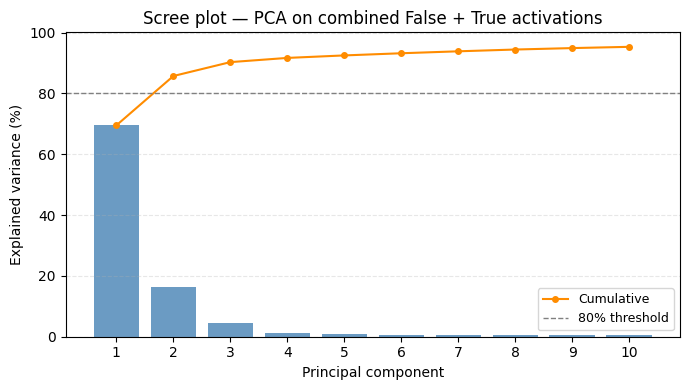

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(range(1, N_COMPONENTS + 1), var, color="steelblue", alpha=0.8)
ax.plot(range(1, N_COMPONENTS + 1), np.cumsum(var),
        color="darkorange", marker="o", markersize=4, linewidth=1.5, label="Cumulative")
ax.axhline(80, color="gray", linestyle="--", linewidth=1, label="80% threshold")

ax.set_xlabel("Principal component")
ax.set_ylabel("Explained variance (%)")
ax.set_title("Scree plot — PCA on combined False + True activations")
ax.set_xticks(range(1, N_COMPONENTS + 1))
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()